# Titanic Dataset Analysis

## Data Science And Data Analytics with Python Internship – Task 2

### Objective
The objective of this project is to analyze the Titanic dataset and identify factors that affected passenger survival.

### Tasks Performed
- Load Titanic dataset
- Clean missing data
- Analyze survival patterns
- Create visualizations using Seaborn and Matplotlib
- Draw insights from the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Step 1: Load the Dataset

In this step, we load the Titanic dataset and preview the first few records.

In [2]:
# Load Titanic Dataset

df = pd.read_csv(r"C:\Users\Dell\Downloads\Titanic-Dataset.csv")

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Step 2: Explore the Dataset

Understanding the dataset structure, columns, and missing values before cleaning.

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(891, 12)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Step 3: Data Cleaning

The Age column contains missing values.

We replace missing Age values with the median age because the median is less affected by outliers.

In [4]:
df["Age"] = df["Age"].fillna(df["Age"].median())

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Question 1

## Who Survived More: Males or Females?

We calculate the survival rate based on gender.

In [5]:
gender_survival = df.groupby("Sex")["Survived"].mean() * 100

print(gender_survival)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


## Visualization: Survival Rate by Gender

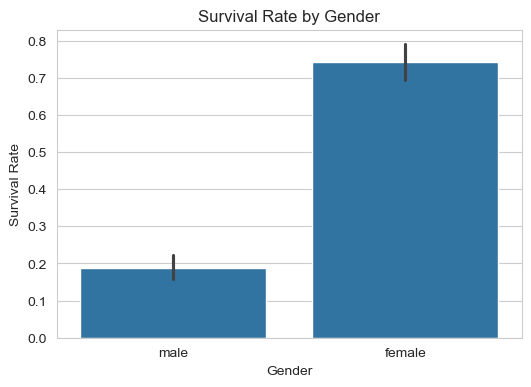

In [6]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Sex",
    y="Survived",
    data=df
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

### Insight

Female passengers had a significantly higher survival rate than male passengers.

# Question 2

## Did Passenger Class Affect Survival Chances?

We analyze survival rates for each passenger class.

In [7]:
class_survival = df.groupby("Pclass")["Survived"].mean() * 100

print(class_survival)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


## Visualization: Survival Rate by Passenger Class

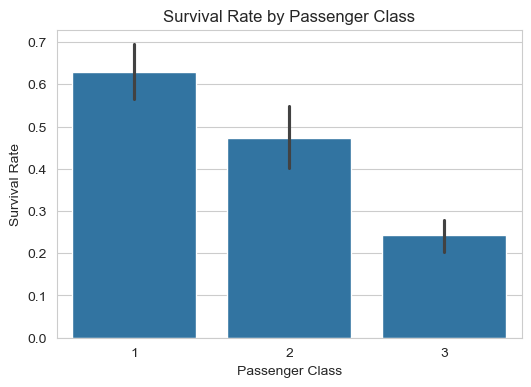

In [8]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Pclass",
    y="Survived",
    data=df
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

### Insight

- First-class passengers had the highest survival rate.
- Third-class passengers had the lowest survival rate.
- Passenger class clearly affected survival chances.

# Question 3

## What Was the Survival Rate by Age Group?

Passengers are divided into age groups to compare survival rates.

In [10]:
bins = [0, 12, 18, 35, 60, 100]

labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Adult",
    "Senior"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

age_group_survival = df.groupby(
    "Age_Group",
    observed=False
)["Survived"].mean() * 100

print("Survival Rate by Age Group (%)")
print(age_group_survival)

Survival Rate by Age Group (%)
Age_Group
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


## Visualization: Survival Rate by Age Group

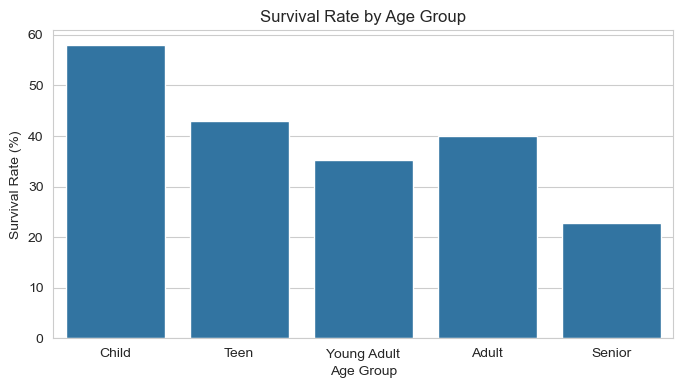

In [11]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=age_group_survival.index,
    y=age_group_survival.values
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")

plt.show()

### Insight

Children generally had better survival chances than adults.

# Passenger Age Distribution

A histogram helps us understand the age distribution of passengers.

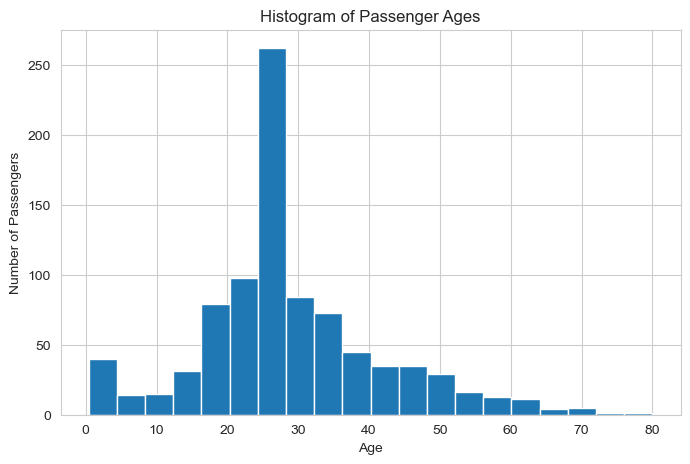

In [12]:
plt.figure(figsize=(8,5))

df["Age"].plot(
    kind="hist",
    bins=20
)

plt.title("Histogram of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

# Analysis Answers

### 1. Who survived more: males or females?
Females survived more than males.

### 2. Did passenger class affect survival chances?
Yes. First-class passengers had better survival chances.

### 3. What was the survival rate by age group?
Children generally had higher survival rates than adults.

# Conclusion

The Titanic dataset analysis revealed several important survival patterns:

- Female passengers had significantly higher survival rates.
- Passenger class strongly influenced survival chances.
- First-class passengers were more likely to survive.
- Children generally had better survival rates.
- Data visualization helped identify these trends effectively.

This analysis demonstrates how data cleaning, exploration, and visualization can be used to answer real-world business questions using data.